
       INDIVIDUAL MODEL PERFORMANCE BENCHMARKS
        Model  Accuracy  Precision   Recall  F1-Score
  Naive Bayes  0.747742   0.990212 0.748920  0.852828
Decision Tree  0.973510   0.975860 0.997532  0.986577
Random Forest  0.989163   0.989018 1.000000  0.994479
      XGBoost  0.986153   0.986010 1.000000  0.992956


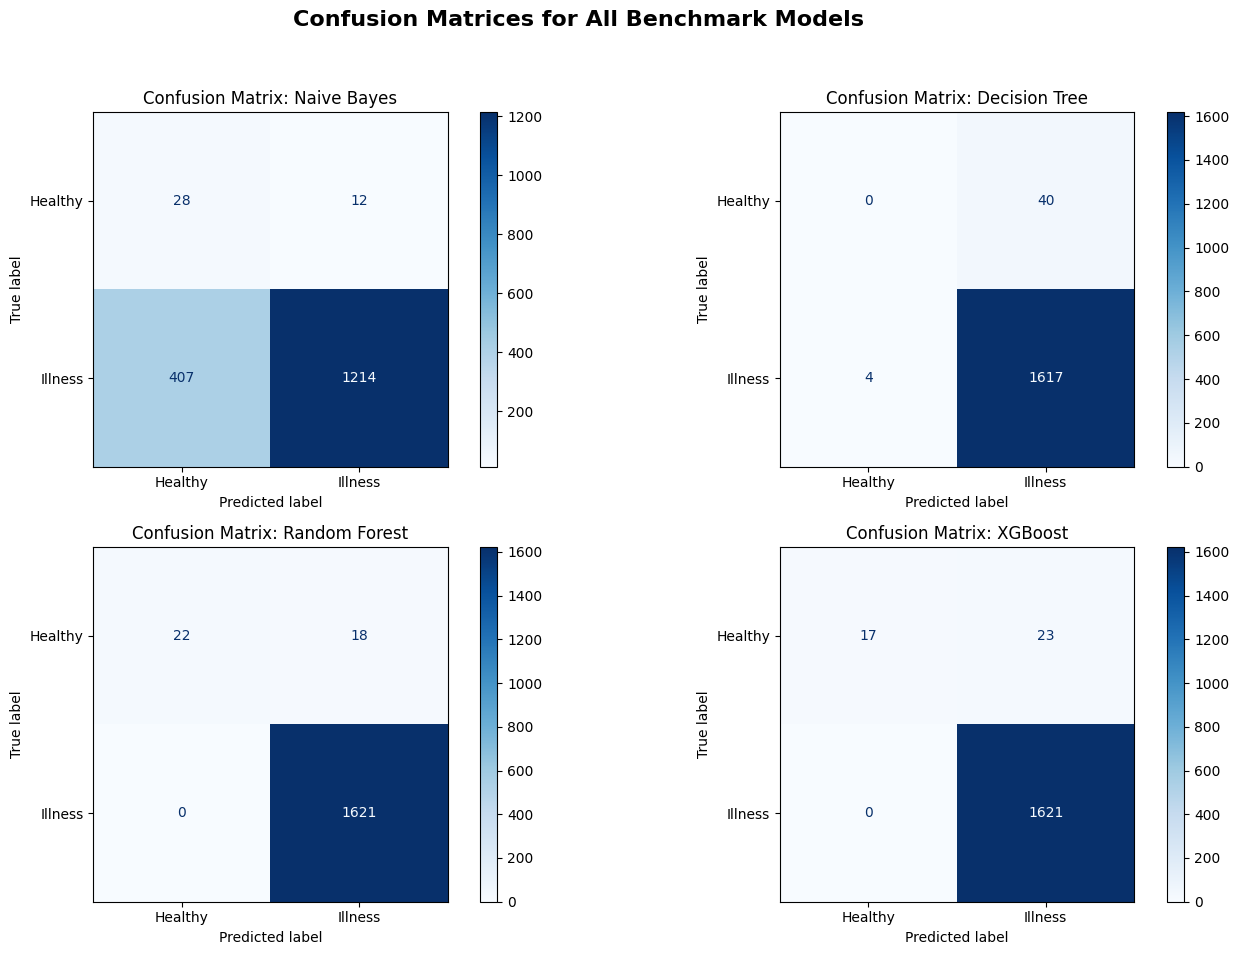

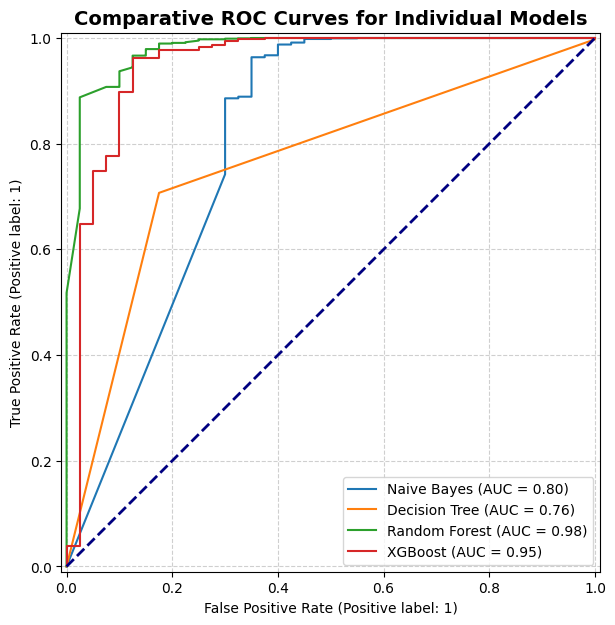

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
# Metrics import karein
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, ConfusionMatrixDisplay, RocCurveDisplay)

# ==============================================================================
# 2. Data Loading & Exploratory Data Analysis (EDA)
# ==============================================================================
df = pd.read_csv("illness_dataset.csv")

# Class conversion for Research: Healthy vs Illness
df.loc[df['Disease'] == 'No illness', 'Disease'] = 0
df.loc[df['Disease'] != 0, 'Disease'] = 1
df['Disease'] = df['Disease'].astype(int)

# Target variable names for plots
class_names = ['Healthy', 'Illness']

# ==============================================================================
# 3. Data Preprocessing & Feature Engineering
# ==============================================================================
X = df.drop('Disease', axis=1)
y = df['Disease']
feature_names = X.columns

# Encoding categorical symptoms
le = LabelEncoder()
for col in X.columns:
    X[col] = le.fit_transform(X[col].astype(str))

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Splitting Data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# ==============================================================================
# 4. Model Training & Metrics Calculation
# ==============================================================================
models = {
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=15, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
}

# Metrics store karne ke liye list
performance_metrics = []

# Individual Model Evaluation
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Metrics calculate karein
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    performance_metrics.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

# Convert to DataFrame for a clean table
metrics_df = pd.DataFrame(performance_metrics)
print("\n" + "="*50)
print("       INDIVIDUAL MODEL PERFORMANCE BENCHMARKS")
print("="*50)
print(metrics_df.to_string(index=False))
print("="*50)

# ==============================================================================
# 5. Confusion Matrix Grid (Updated for 4 models)
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=axes[i], cmap='Blues', display_labels=class_names)
    axes[i].set_title(f"Confusion Matrix: {name}")

plt.suptitle("Confusion Matrices for All Benchmark Models", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ==============================================================================
# 6. ROC Curve Grid
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 7))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title("Comparative ROC Curves for Individual Models", fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [9]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# 1. Define Base Learners (Level-0)

base_learners = [
    ('dt', DecisionTreeClassifier(max_depth=15, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(n_estimators=200, learning_rate=0.1, random_state=42))
]

# 2. Initialize Stacked Ensemble with Meta-Learner (Level-1)
ensemble_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)

# 3. Train the Ensemble
print("Training Stacked Ensemble... Please wait.")
ensemble_model.fit(X_train, y_train)

# 4. Predict and Calculate Metrics
y_pred_ensemble = ensemble_model.predict(X_test)

# Metrics calculation
ensemble_acc = accuracy_score(y_test, y_pred_ensemble)
ensemble_prec = precision_score(y_test, y_pred_ensemble)
ensemble_rec = recall_score(y_test, y_pred_ensemble)
ensemble_f1 = f1_score(y_test, y_pred_ensemble)

# 5. Display Ensemble Results
print("\n" + "="*30)
print(" FINAL ENSEMBLE METRICS")
print("="*30)
print(f"Accuracy  : {ensemble_acc*100:.2f}%")
print(f"Precision : {ensemble_prec:.4f}")
print(f"Recall    : {ensemble_rec:.4f}")
print(f"F1-Score  : {ensemble_f1:.4f}")
print("="*30)

# Classification Report for full detail
print("\nEnsemble Detailed Report:")
print(classification_report(y_test, y_pred_ensemble, target_names=['Healthy', 'Illness']))

Training Stacked Ensemble... Please wait.

 FINAL ENSEMBLE METRICS
Accuracy  : 98.92%
Precision : 0.9890
Recall    : 1.0000
F1-Score  : 0.9945

Ensemble Detailed Report:
              precision    recall  f1-score   support

     Healthy       1.00      0.55      0.71        40
     Illness       0.99      1.00      0.99      1621

    accuracy                           0.99      1661
   macro avg       0.99      0.78      0.85      1661
weighted avg       0.99      0.99      0.99      1661



<Figure size 700x600 with 0 Axes>

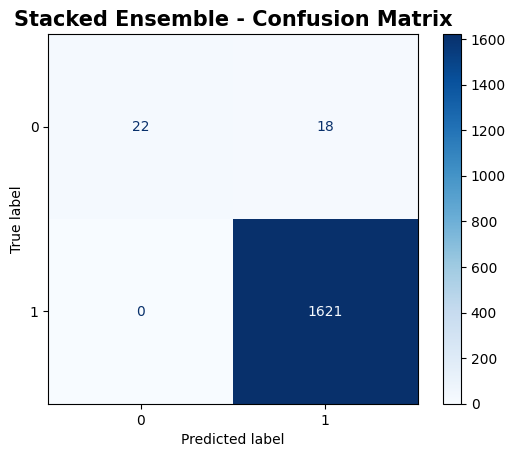

<Figure size 700x600 with 0 Axes>

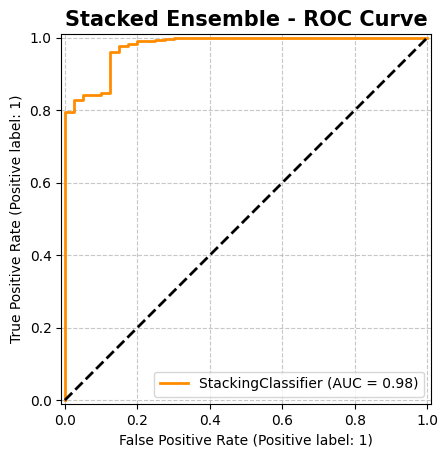

In [11]:
# 1. Ensure the ensemble is already trained
# ensemble.fit(X_train, y_train)

# 2. Confusion Matrix (Single Figure)
plt.figure(figsize=(7, 6))
cm_display = ConfusionMatrixDisplay.from_estimator(
    ensemble_model,
    X_test,
    y_test,
    cmap='Blues',
    values_format='d'
)
plt.title("Stacked Ensemble - Confusion Matrix", fontsize=15, fontweight='bold')
plt.grid(False)
plt.show()

# 3. ROC Curve (Single Figure)
plt.figure(figsize=(7, 6))
roc_display = RocCurveDisplay.from_estimator(
    ensemble_model,
    X_test,
    y_test,
    color='darkorange',
    linewidth=2
)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2)
plt.title("Stacked Ensemble - ROC Curve", fontsize=15, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

  0%|          | 0/20 [00:00<?, ?it/s]

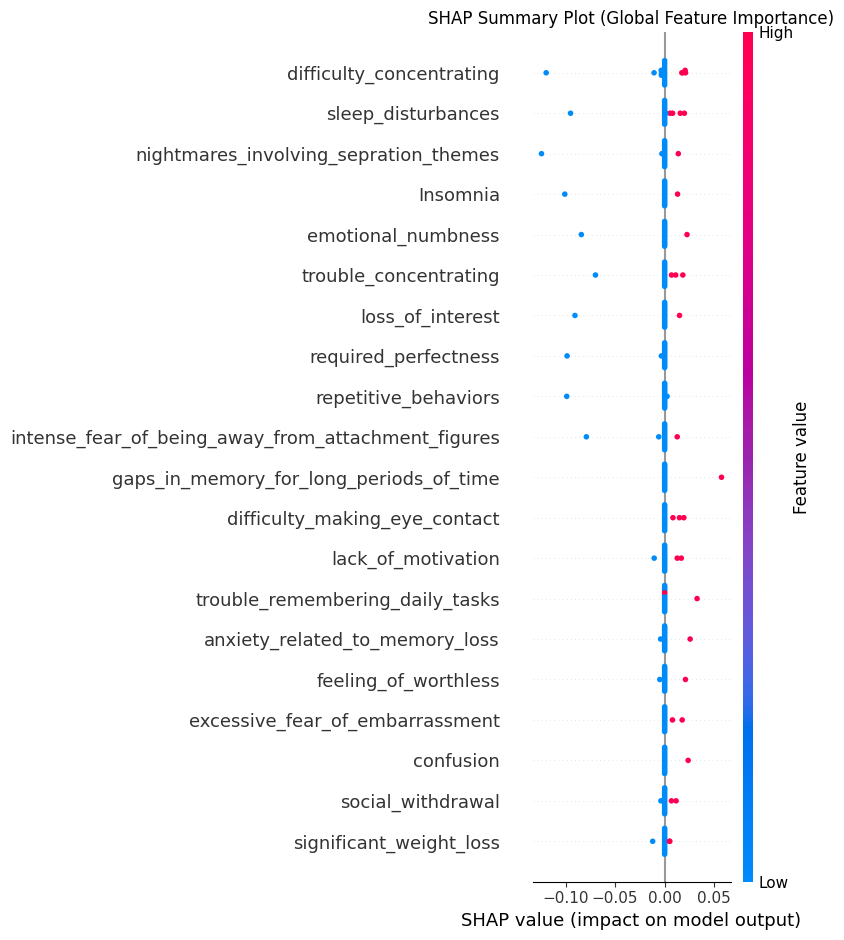

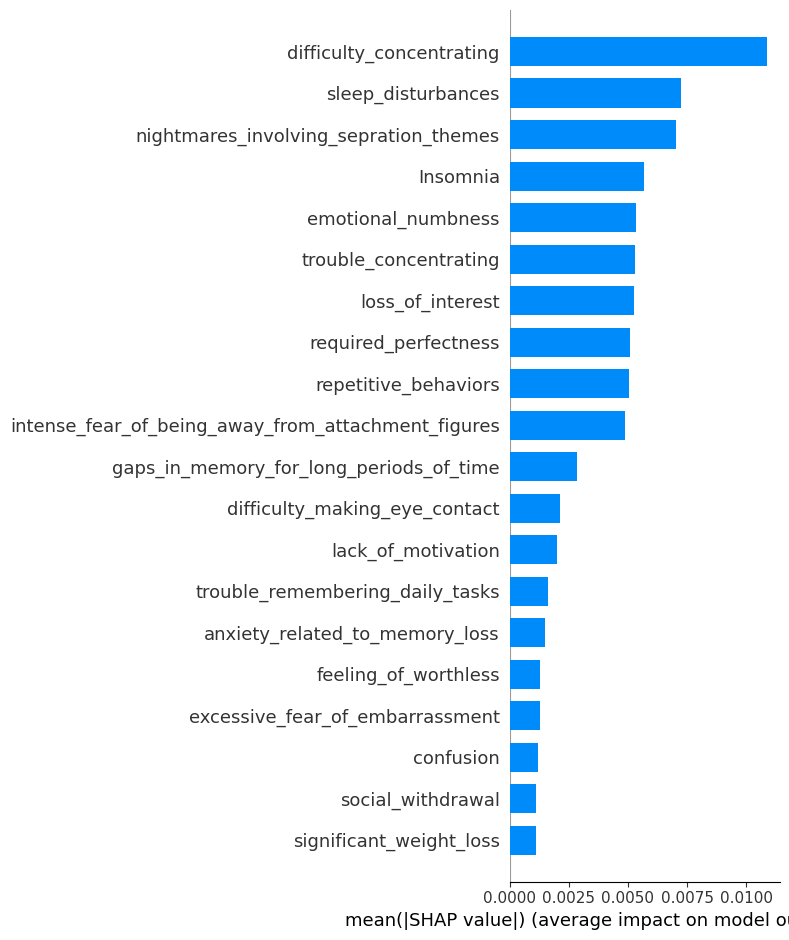

In [12]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize SHAP Explainer

explainer = shap.KernelExplainer(ensemble_model.predict, X_train[:50])
shap_values = explainer.shap_values(X_test[:20]) # First 20 samples for clarity

# 2. SHAP Summary Plot (Global Importance)

plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot (Global Feature Importance)")
shap.summary_plot(shap_values, X_test[:20], feature_names=feature_names)

# 3. SHAP Bar Plot (Aggregated Importance)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test[:20], feature_names=feature_names, plot_type="bar")

